# 01 - Exploratory Data Analysis
Exploratory data analysis and class-balance review for the mule-detection datasets.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\Marah\\Desktop\\Third Trimester\\Final Project\\final-project-EADA\\data\\processed\\master.csv")
df.head()

,cuenta,dato_persona_titular,tipo_de_persona_titular,pais_de_nacimiento,pais_de_nacionalidad_titular,pais_residencia_ok,provincia_ok,fecha_de_nacimiento,tipo_de_documento,balance_2025_12_31,...,n_tx_interest,n_tx_other,n_tx_transfer,n_tx_fee,n_tx_opening,n_tx_bizum,n_tx_card,n_tx_seizure,n_tx_salary,n_tx_investment
0,67d81bac6f04845c0a778f3bf964e0aecd6505f1f9ef80...,43858931b06e067ec3ac87507c8023be8c35af00ccd70e...,F,ESPAÑA,ESPAÑA,ESPAÑA,VALENCIA,1986-08-26,NIF-DNI,0.70,...,15,0,10,0,1,0,0,0,0,0
1,baead52a12470b33a0943eb506568e46c56851483670a2...,e616dca839c4ca66fe8c099c99adba25cb21ed45d80940...,F,PERU,PERU,ESPAÑA,MADRID,1976-02-22,TARJ RESIDENTE,2.03,...,15,0,14,0,1,0,0,0,0,0
2,4663412acc863b1642aea0327cd5fc3a128e6cb81574f5...,8b09892729c8833008075e0552c318b7cb1bbf6964153c...,F,ESPAÑA,ESPAÑA,ESPAÑA,SEVILLA,2003-09-16,NIF-DNI,2.42,...,15,0,18,0,0,5,0,0,2,0
3,587ae695a93f0ddda5bd25418a90ac24b31ab55195517e...,331ef9bf6281d15beb9ae83c811e29c64e96996978f460...,F,ESPAÑA,ESPAÑA,ESPAÑA,MADRID,1990-07-27,NIF-DNI,1.00,...,14,0,1,0,1,0,0,0,0,0
4,5c095af73343e6bab224edccebd526d34b09909388dfb2...,3cd27beca0c9fb619528fabb08288a89ccb226d8732e7d...,F,RUMANIA,RUMANIA,ESPAÑA,ALICANTE,1991-06-04,TARJ RESIDENTE,41.35,...,8,0,17,0,0,15,0,0,0,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2055 entries, 0 to 2054
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   cuenta                        2055 non-null   object 
 1   dato_persona_titular          2055 non-null   object 
 2   tipo_de_persona_titular       2055 non-null   object 
 3   pais_de_nacimiento            2052 non-null   object 
 4   pais_de_nacionalidad_titular  2055 non-null   object 
 5   pais_residencia_ok            2055 non-null   object 
 6   provincia_ok                  2055 non-null   object 
 7   fecha_de_nacimiento           2055 non-null   object 
 8   tipo_de_documento             2055 non-null   object 
 9   balance_2025_12_31            2055 non-null   float64
 10  os                            1199 non-null   object 
 11  device_name                   1199 non-null   object 
 12  device_brand                  563 non-null    object 
 13  dev

In [42]:
distinct_counts = df.nunique(dropna=False)
for col, count in distinct_counts.items():
    print(f"{col}: {count}")

cuenta: 2055
dato_persona_titular: 1915
tipo_de_persona_titular: 1
pais_de_nacimiento: 29
pais_de_nacionalidad_titular: 19
pais_residencia_ok: 1
provincia_ok: 52
fecha_de_nacimiento: 1798
tipo_de_documento: 2
balance_2025_12_31: 907
os: 3
device_name: 402
device_brand: 23
device_model: 207
age_years: 1539
n_transactions: 42
n_credits: 41
n_debits: 36
total_credit: 1643
total_debit: 1447
gross_volume: 1677
mean_abs_amount: 1749
max_abs_amount: 868
first_tx_date: 477
last_tx_date: 73
n_unique_descriptions: 13
net_flow: 1246
tx_window_days: 280
days_since_last_tx: 73
n_tx_interest: 39
n_tx_other: 21
n_tx_transfer: 34
n_tx_fee: 13
n_tx_opening: 3
n_tx_bizum: 36
n_tx_card: 24
n_tx_seizure: 4
n_tx_salary: 6
n_tx_investment: 15


In [47]:
distinct_counts = df.nunique(dropna=False)
print(distinct_counts.to_dict())

{'cuenta': 2055, 'dato_persona_titular': 1915, 'tipo_de_persona_titular': 1, 'pais_de_nacimiento': 29, 'pais_de_nacionalidad_titular': 19, 'pais_residencia_ok': 1, 'provincia_ok': 52, 'fecha_de_nacimiento': 1798, 'tipo_de_documento': 2, 'balance_2025_12_31': 907, 'os': 3, 'device_name': 402, 'device_brand': 23, 'device_model': 207, 'age_years': 1539, 'n_transactions': 42, 'n_credits': 41, 'n_debits': 36, 'total_credit': 1643, 'total_debit': 1447, 'gross_volume': 1677, 'mean_abs_amount': 1749, 'max_abs_amount': 868, 'first_tx_date': 477, 'last_tx_date': 73, 'n_unique_descriptions': 13, 'net_flow': 1246, 'tx_window_days': 280, 'days_since_last_tx': 73, 'n_tx_interest': 39, 'n_tx_other': 21, 'n_tx_transfer': 34, 'n_tx_fee': 13, 'n_tx_opening': 3, 'n_tx_bizum': 36, 'n_tx_card': 24, 'n_tx_seizure': 4, 'n_tx_salary': 6, 'n_tx_investment': 15}


*Findings*
We have to drop columns cuenta and dato_persona_titular because they are not relevant for the model.

## Missing Values

In [24]:
df.isna().sum().sort_values(ascending=False)

device_model                    1492
device_brand                    1492
device_name                      856
os                               856
pais_de_nacimiento                 3
mean_abs_amount                    1
last_tx_date                       1
tx_window_days                     1
days_since_last_tx                 1
first_tx_date                      1
max_abs_amount                     1
n_tx_transfer                      0
n_tx_fee                           0
n_tx_opening                       0
n_tx_other                         0
n_tx_interest                      0
n_tx_bizum                         0
n_tx_card                          0
net_flow                           0
n_unique_descriptions              0
n_tx_seizure                       0
n_tx_salary                        0
cuenta                             0
total_debit                        0
gross_volume                       0
dato_persona_titular               0
total_credit                       0
n

In [25]:
#To Know the percentage of missing values in each column
missing = df.isna().mean().sort_values(ascending=False) * 100
missing

device_model                    72.603406
device_brand                    72.603406
device_name                     41.654501
os                              41.654501
pais_de_nacimiento               0.145985
mean_abs_amount                  0.048662
last_tx_date                     0.048662
tx_window_days                   0.048662
days_since_last_tx               0.048662
first_tx_date                    0.048662
max_abs_amount                   0.048662
n_tx_transfer                    0.000000
n_tx_fee                         0.000000
n_tx_opening                     0.000000
n_tx_other                       0.000000
n_tx_interest                    0.000000
n_tx_bizum                       0.000000
n_tx_card                        0.000000
net_flow                         0.000000
n_unique_descriptions            0.000000
n_tx_seizure                     0.000000
n_tx_salary                      0.000000
cuenta                           0.000000
total_debit                      0

In [34]:
#checking if empty values are in the same row
cols = [
    "mean_abs_amount",
    "last_tx_date",
    "tx_window_days",
    "days_since_last_tx",
    "first_tx_date",
    "max_abs_amount",
]
missing_row = df[df[cols].isna().all(axis=1)]
missing_row

,cuenta,dato_persona_titular,tipo_de_persona_titular,pais_de_nacimiento,pais_de_nacionalidad_titular,pais_residencia_ok,provincia_ok,fecha_de_nacimiento,tipo_de_documento,balance_2025_12_31,...,n_tx_interest,n_tx_other,n_tx_transfer,n_tx_fee,n_tx_opening,n_tx_bizum,n_tx_card,n_tx_seizure,n_tx_salary,n_tx_investment
1768,04dea72656796f6312fdc9aa10dabcce60abfa58cae1be...,694807d2cbb71c52531b04aa726158e1c34d9d9d49bb53...,F,ESPAÑA,ESPAÑA,ESPAÑA,BARCELONA,1980-11-13,NIF-DNI,-192.18,...,0,0,0,0,0,0,0,0,0,0


*Findings*
* device_model and device_brand have 72.6% of missing values (delete columns)
* device_name and os have 41.65% of missing values (delete columns)
* pais_de_nacimiento have 0.14% of missing values (to be filled with mode)
* mean_abs_amount, last_tx_date ,tx_window_days, days_since_last_tx, first_tx_date,max_abs_amount have 0.04% of missing values (this is the same row, it needs to be deleted) 


## Column Types

In [38]:
# review categorical variables
categorical_variables = df.columns[df.dtypes == "object"].tolist()
print(df.columns[df.dtypes == "object"].tolist())
len(categorical_variables)


['cuenta', 'dato_persona_titular', 'tipo_de_persona_titular', 'pais_de_nacimiento', 'pais_de_nacionalidad_titular', 'pais_residencia_ok', 'provincia_ok', 'fecha_de_nacimiento', 'tipo_de_documento', 'os', 'device_name', 'device_brand', 'device_model', 'first_tx_date', 'last_tx_date']


15

*Findings*
There are 15 categorical columns. As mentioned above:
* we will be dropping the first two columns (cuenta and dato_persona_titular) as they are irrelevant
*  we will be dropping the four columns device_model, device_brand, device_name and os as they have many missing values
* column (tipo_de_persona_titular) is binary, so it is not considered categorical

we will end up with 8 categorical columns
Given that we have 39 columns, and 15 of them are "categorical", we have have 24 numerical columns


*Final Findings*
* Categorical = 8
* Numerical = 24  (Out of which 3 are dates: fecha_de_nacimiento, first_tx_date and last_tx_date)
* Binary = 1 

* Considering that columns tipo_de_persona_titular and pais_residencia_ok currently have only one value, and tipo_de_documento has 2 values. These columns to be rechecked once we receive the rest of the dataset. 
* We are also missing the column Y for the model since we ONLY received mules :/

## Visualization of data

### Numerical Variables

In [53]:
numerical_variables = df.drop(columns=categorical_variables).columns
print(numerical_variables)
len(numerical_variables)

Index(['balance_2025_12_31', 'age_years', 'n_transactions', 'n_credits',
       'n_debits', 'total_credit', 'total_debit', 'gross_volume',
       'mean_abs_amount', 'max_abs_amount', 'n_unique_descriptions',
       'net_flow', 'tx_window_days', 'days_since_last_tx', 'n_tx_interest',
       'n_tx_other', 'n_tx_transfer', 'n_tx_fee', 'n_tx_opening', 'n_tx_bizum',
       'n_tx_card', 'n_tx_seizure', 'n_tx_salary', 'n_tx_investment'],
      dtype='object')


24

In [55]:
df[numerical_variables].describe()

,balance_2025_12_31,age_years,n_transactions,n_credits,n_debits,total_credit,total_debit,gross_volume,mean_abs_amount,max_abs_amount,n_unique_descriptions,net_flow,tx_window_days,days_since_last_tx,n_tx_interest,n_tx_other,n_tx_transfer,n_tx_fee,n_tx_opening,n_tx_bizum,n_tx_card,n_tx_seizure,n_tx_salary,n_tx_investment
count,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2054.000000,2054.000000,2055.000000,2055.000000,2054.000000,2054.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000
mean,594.600526,37.898550,22.948418,17.229197,5.719221,8660.991669,-8377.614555,17038.606224,734.070051,4672.517975,4.356204,283.377114,347.396300,-93.076923,11.539173,0.475426,5.769343,0.154745,0.847202,3.646229,0.263747,0.056934,0.069586,0.126034
std,3816.216506,14.469244,10.232462,6.225753,6.721943,18804.960975,18810.913692,37493.345431,1430.285206,8444.825322,1.459492,3033.662920,144.103415,87.031215,4.884279,1.948773,5.725150,0.945648,0.361231,7.625605,2.108896,0.266919,0.365936,1.432404
min,-2538.810000,18.180000,0.000000,0.000000,0.000000,0.000000,-239910.000000,0.000000,0.000000,0.000000,0.000000,-41947.630000,0.000000,-118.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.010000,25.360000,15.000000,13.000000,1.000000,36.485000,-8200.000000,81.020000,4.550441,25.250000,3.000000,0.000000,275.000000,-110.000000,9.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.560000,34.970000,20.000000,16.000000,3.000000,1300.370000,-1252.000000,2652.600000,103.262050,581.000000,4.000000,1.000000,336.000000,-103.000000,11.000000,0.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,17.075000,48.015000,30.000000,20.000000,8.000000,8815.510000,-20.000000,17099.470000,737.447009,5000.000000,5.000000,11.110000,397.000000,-95.000000,13.000000,0.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000
max,94635.399024,87.450000,80.000000,54.000000,35.000000,240022.970000,0.000000,479932.970000,15241.785385,99000.000000,12.000000,50445.450000,1186.000000,1645.000000,40.000000,31.000000,34.000000,16.000000,2.000000,44.000000,37.000000,3.000000,5.000000,28.000000


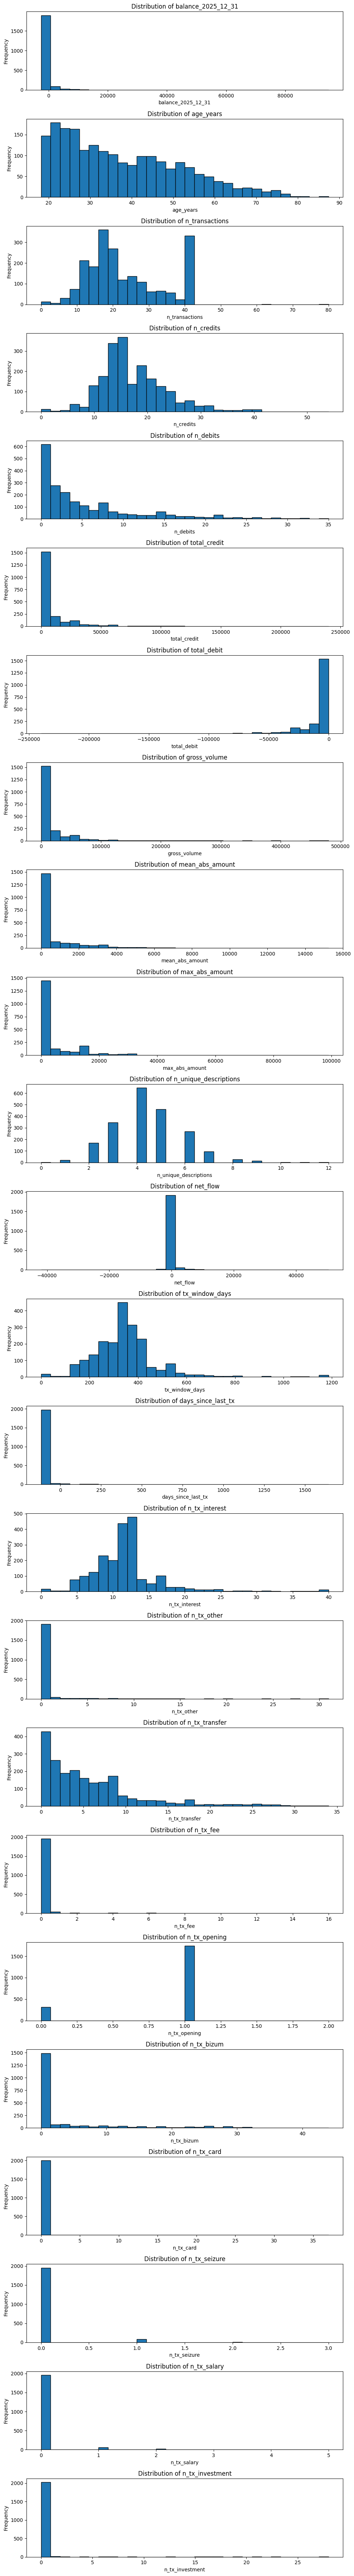

In [ ]:
def plot_numeric_distributions(df, columns=None, log_scale=False):
    """Plot histograms for numeric columns."""
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns
    
    n_cols = len(columns)
    fig, axes = plt.subplots(n_cols, 1, figsize=(10, 3*n_cols))
    
    if n_cols == 1:
        axes = [axes]
    
    for ax, col in zip(axes, columns):
        ax.hist(df[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        if log_scale:
            ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

# Usage:
plot_numeric_distributions(df, columns=numerical_variables, log_scale=False)

In [71]:


def outlier_report(df, columns=None, method="iqr", threshold=3.0):
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    rows = []
    indices_map = {}

    for col in columns:
        s = df[col]
        non_na = s.dropna()
        if non_na.empty:
            rows.append({"column": col, "count": 0, "percent": 0.0, "lower_bound": None, "upper_bound": None, "sample_indices": []})
            indices_map[col] = []
            continue

        if method.lower() == "iqr":
            q1 = non_na.quantile(0.25)
            q3 = non_na.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - threshold * iqr
            upper = q3 + threshold * iqr
            mask = (s < lower) | (s > upper)
        elif method.lower() in ("zscore", "z"):
            mean = non_na.mean()
            std = non_na.std()
            if std == 0 or np.isnan(std):
                mask = pd.Series(False, index=s.index)
            else:
                z = (s - mean) / std
                mask = z.abs() > threshold
            lower = upper = None
        else:
            raise ValueError("method must be 'iqr' or 'zscore'")

        out_idx = s.index[mask.fillna(False)].tolist()
        count = len(out_idx)
        percent = 100.0 * count / len(df)
        rows.append({
            "column": col,
            "count": int(count),
            "percent": float(percent),
            "lower_bound": (float(lower) if lower is not None else None),
            "upper_bound": (float(upper) if upper is not None else None),
            "sample_indices": out_idx[:20],
        })
        indices_map[col] = out_idx

    report = pd.DataFrame(rows).sort_values("percent", ascending=False).reset_index(drop=True)
    return report, indices_map

report, indices = outlier_report(df, method="iqr", threshold=1.5)
print(report.to_string())

                   column  count    percent  lower_bound   upper_bound                                                                                                   sample_indices
0                net_flow    604  29.391727    -16.66500     27.775000                                     [2, 4, 6, 8, 13, 22, 23, 25, 28, 30, 41, 48, 50, 53, 55, 56, 71, 75, 76, 77]
1      balance_2025_12_31    440  21.411192    -25.58750     42.672500                            [13, 23, 25, 28, 30, 41, 48, 50, 56, 73, 79, 82, 84, 94, 99, 101, 105, 109, 112, 123]
2              n_tx_bizum    396  19.270073     -3.00000      5.000000                                    [4, 5, 6, 8, 23, 31, 34, 43, 46, 55, 67, 71, 74, 75, 76, 77, 78, 91, 92, 103]
3          max_abs_amount    341  16.593674  -7436.87500  12462.125000                               [12, 13, 14, 18, 19, 21, 22, 25, 26, 29, 30, 41, 50, 51, 53, 62, 63, 66, 129, 170]
4            n_tx_opening    316  15.377129      1.00000      1.000000          

In [72]:
#Outliers detection using Z-score method
report, indices = outlier_report(df, method="zscore", threshold=3.0)
print(report.to_string())

                   column  count   percent lower_bound upper_bound                                                                                                            sample_indices
0            n_tx_seizure    101  4.914842        None        None                                 [6, 16, 21, 38, 48, 55, 73, 82, 84, 86, 116, 171, 190, 208, 246, 294, 343, 353, 483, 491]
1              n_tx_bizum     69  3.357664        None        None                         [43, 71, 75, 120, 238, 303, 312, 322, 353, 374, 389, 390, 410, 541, 587, 633, 680, 683, 691, 702]
2           n_tx_transfer     56  2.725061        None        None                          [22, 28, 48, 82, 122, 140, 144, 150, 175, 182, 196, 407, 436, 466, 482, 532, 598, 611, 613, 645]
3                n_debits     48  2.335766        None        None                     [75, 94, 115, 356, 374, 393, 410, 462, 640, 698, 699, 702, 718, 887, 957, 986, 995, 1009, 1010, 1022]
4         mean_abs_amount     44  2.141119        None 

*Findings*
Outliers should be found using the IQR method. Since the dataset consists exclusively of confirmed mule accounts, detected outliers are not assumed to be data errors. Instead, they may represent extreme but legitimate mule-account behaviors and therefore were retained for further analysis

Theres A LOT! Daniel is going to be ENRAGED!!


### Categorical Variables

In [91]:
# Exclude the first 2 categorical columns (cuenta, dato_persona_titular) that will be deleted
categorical_to_plot = categorical_variables[2:]

# Plot each column with value counts
for col in categorical_to_plot:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    value_counts = df[col].value_counts(dropna=False)
    print(value_counts)
    print(f"\nTotal non-null: {df[col].notna().sum()}, Missing: {df[col].isna().sum()}\n")


Column: tipo_de_persona_titular
tipo_de_persona_titular
F    2055
Name: count, dtype: int64

Total non-null: 2055, Missing: 0


Column: pais_de_nacimiento
pais_de_nacimiento
ESPAÑA                  1892
MARRUECOS                 21
COLOMBIA                  19
REPUBLICA DOMINICANA      18
ECUADOR                   16
BRASIL                    12
BOLIVIA                   10
PERU                       9
ARGENTINA                  8
FRANCIA                    7
RUMANIA                    5
SUIZA                      4
URUGUAY                    4
CHILE                      3
HONDURAS                   3
POLONIA                    3
PARAGUAY                   3
NaN                        3
FILIPINAS                  2
ALEMANIA                   2
VENEZUELA                  2
UCRANIA                    2
PAISES BAJOS               1
MEXICO                     1
NIGERIA                    1
ITALIA                     1
CUBA                       1
COSTA RICA                 1
RUSIA        

*Findings* 
These are the different categories and counts. 

### Temporal Visualization 

###

C:\Users\Marah\AppData\Local\Temp\ipykernel_29276\1700580233.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  result = df_temp.groupby(pd.Grouper(key=date_col, freq=freq)).size().reset_index(name='transaction_count')


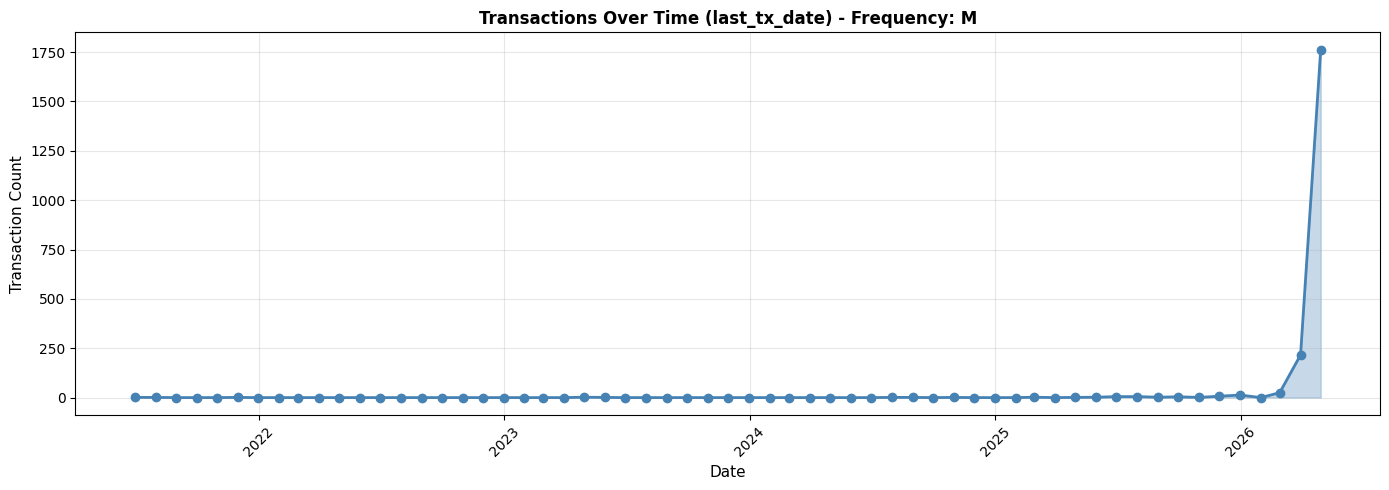

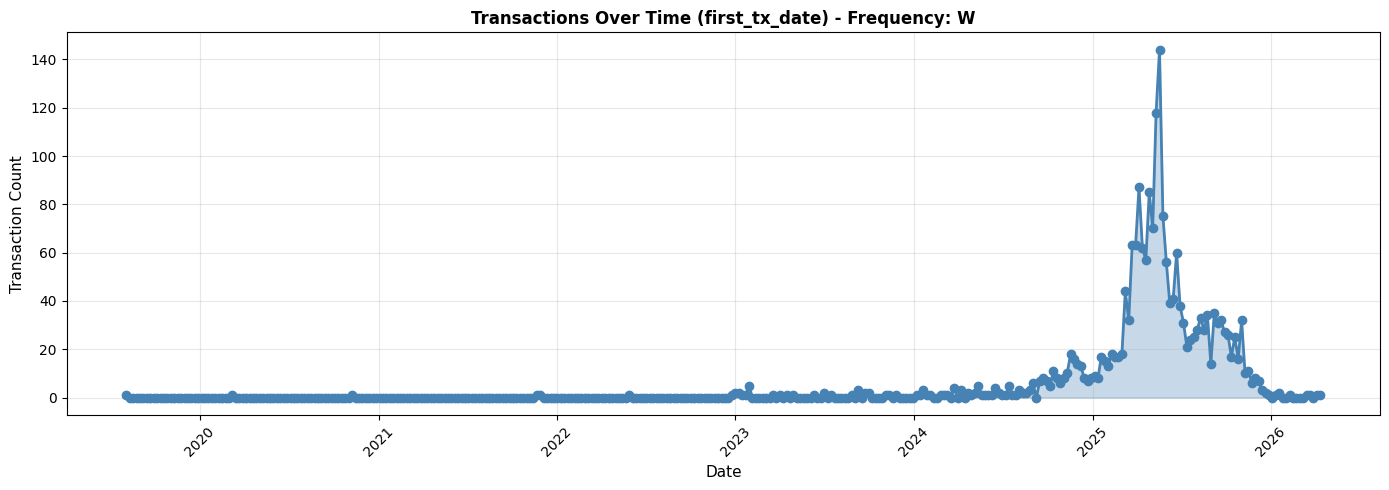

In [94]:
def plot_transactions_over_time(df, date_col, freq="M"):
    """
    Plot transaction counts over time periods.
    
    Parameters:
    - df: DataFrame containing transaction data
    - date_col: name of date column (e.g., 'last_tx_date', 'first_tx_date')
    - freq: pandas frequency ('D' = daily, 'W' = weekly, 'M' = monthly, 'Q' = quarterly, 'Y' = yearly)
    """
    # Get aggregated data using the transactions_per_period function
    tx_data = transactions_per_period(df, date_col, freq=freq)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Plot line with markers and filled area
    ax.plot(tx_data[date_col], tx_data['transaction_count'], 
            marker='o', linewidth=2, markersize=6, color='steelblue', label='Transactions')
    ax.fill_between(tx_data[date_col], tx_data['transaction_count'], 
                    alpha=0.3, color='steelblue')
    
    ax.set_title(f'Transactions Over Time ({date_col}) - Frequency: {freq}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Transaction Count', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Usage:
plot_transactions_over_time(df, 'last_tx_date', freq='M')
plot_transactions_over_time(df, 'first_tx_date', freq='W')

*Findings*
Most of the first transactions happened in 2025 and last in 2026.

### Correlations 

                       balance_2025_12_31  age_years  n_transactions  \
balance_2025_12_31               1.000000  -0.019303        0.009263   
age_years                       -0.019303   1.000000        0.092773   
n_transactions                   0.009263   0.092773        1.000000   
n_credits                       -0.009630   0.153701        0.771361   
n_debits                         0.023020  -0.001132        0.807826   
total_credit                     0.160042   0.134871        0.114143   
total_debit                     -0.069890  -0.145167       -0.132347   
gross_volume                     0.115335   0.140477        0.123649   
mean_abs_amount                  0.149218   0.065740        0.013203   
max_abs_amount                   0.165867   0.060711        0.017267   
n_unique_descriptions            0.027495  -0.047716        0.385389   
net_flow                         0.558691  -0.064107       -0.113103   
tx_window_days                  -0.033013   0.164371        0.31

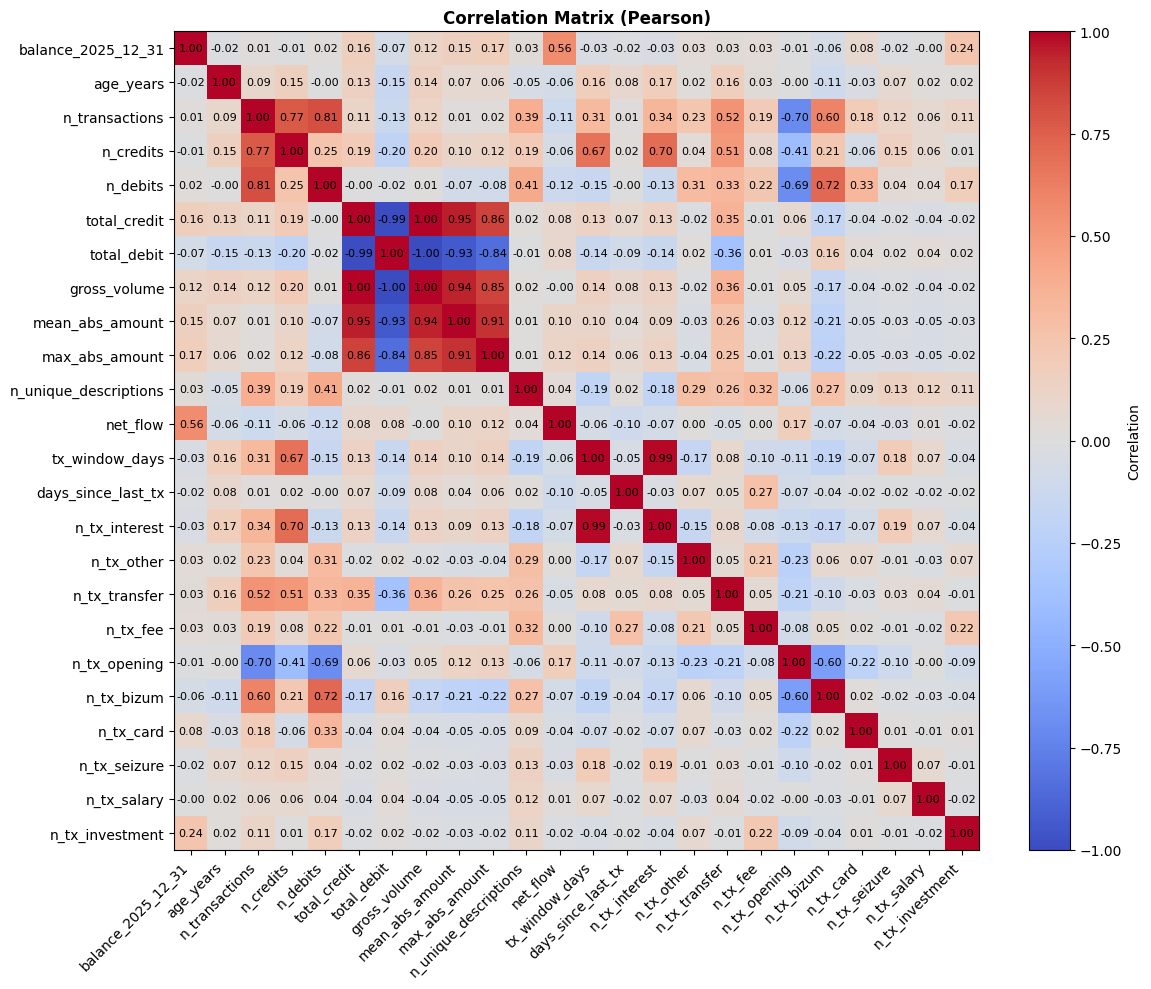

In [95]:
def correlation_matrix(df, method="pearson", target_col=None):
    """
    Compute correlation matrix for numeric columns.
    
    Parameters:
    - df: DataFrame
    - method: "pearson" or "spearman"
    - target_col: optional target column for univariate correlation computation
    
    Returns:
    - pd.DataFrame correlation matrix
    """
    numeric_df = df.select_dtypes(include=[np.number])
    
    if method.lower() == "pearson":
        corr = numeric_df.corr(method='pearson')
    elif method.lower() == "spearman":
        corr = numeric_df.corr(method='spearman')
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")
    
    return corr


def plot_correlation_heatmap(df, method="pearson", figsize=(12, 10)):
    """
    Plot correlation heatmap for numeric columns.
    
    Parameters:
    - df: DataFrame
    - method: "pearson" or "spearman"
    - figsize: figure size (width, height)
    """
    corr = correlation_matrix(df, method=method)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    im = ax.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr.columns)
    
    # Add correlation values in cells
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            text = ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title(f'Correlation Matrix ({method.capitalize()})', 
                 fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.show()


def mutual_information_with_target(df, target_col):
    """
    Compute mutual information between all numeric columns and target.
    
    Parameters:
    - df: DataFrame
    - target_col: target column name (must be numeric or discretized)
    
    Returns:
    - pd.Series with MI scores for each column
    """
    from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove(target_col) if target_col in numeric_cols else None
    
    X = df[numeric_cols].fillna(df[numeric_cols].mean())
    y = df[target_col].fillna(df[target_col].mean())
    
    # Use regression MI if target is continuous, classification if discrete
    if df[target_col].nunique() <= 10:  # Likely categorical
        mi_scores = mutual_info_classif(X, y.astype(int), random_state=42)
    else:  # Continuous
        mi_scores = mutual_info_regression(X, y, random_state=42)
    
    mi_df = pd.DataFrame({
        'feature': numeric_cols,
        'mutual_information': mi_scores
    }).sort_values('mutual_information', ascending=False)
    
    return mi_df


# Usage:
corr_pearson = correlation_matrix(df, method="pearson")
print(corr_pearson)

plot_correlation_heatmap(df, method="pearson")

# Optional: Mutual information with target (if you have a target column)
# mi_scores = mutual_information_with_target(df, target_col='your_target')
# print(mi_scores)

*Findings*
All the variables that are related to the mount of money or debt that the account has are highly correlated meaning that these variables might be redundant for the model. 